# Model comparison and rankings — VGC Bradley-Terry

Loads the NUTS posteriors (additive `nuts_syn0` and synergy `nuts_syn4`) and produces:

1. comparison of the `tau` scales between the two models
2. **Pokémon** ranking (species effect)
3. **item** and **move** rankings
4. **top complete teams** rebuilt from real teamlists (species + ability + item + moves)
5. strongest **synergy pairs** (synergy model only)

Estimates are from NUTS, so intervals are reliable. Every ranking should be read
**by interval, not by mean**: an effect whose interval crosses zero is not established by
the data.

## Setup

In [1]:
from pathlib import Path
import json, collections
import numpy as np, pandas as pd
import arviz as az, xarray as xr
import matplotlib.pyplot as plt

# --- paths: adjust if the files are not under models/ ---
ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
MODELS  = ROOT / "models"
DATA    = ROOT / "data"
RESULTS = ROOT / "results"; RESULTS.mkdir(exist_ok=True)
FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)

ALL_BLOCKS = ["species", "ability", "item", "nature", "moves"]

def load(tag):
    idata = az.from_netcdf(MODELS / f"bt_posterior_{tag}.nc")
    art = json.load(open(MODELS / f"bt_artifacts_{tag}.json", encoding="utf-8"))
    return idata, idata.posterior, art

idata0, post0, art0 = load("nuts_syn0")   # additive
idata4, post4, art4 = load("nuts_syn4")   # with synergy
print("additive:", art0["config"]["n_matches"], "matches,", art0["config"]["n_players_effect"], "players")
print("synergy :", art4["config"]["synergy_dim"], "latent dims")

additive: 17581 matches, 1657 players
synergy : 4 latent dims


## 1. `tau` scale comparison
How much each dimension weighs, in both models. The player dominates; among team features,
species / item / ability are indistinguishable (overlapping intervals).

,add_mean,add_q5,add_q95,syn_mean,syn_q5,syn_q95
block,,,,,,
species,0.096,0.053,0.137,0.064,0.011,0.118
ability,0.107,0.068,0.148,0.099,0.057,0.140
item,0.102,0.064,0.142,0.086,0.045,0.129
nature,0.058,0.028,0.101,0.061,0.029,0.103
moves,0.077,0.063,0.093,0.071,0.056,0.087
player,0.550,0.509,0.594,0.551,0.507,0.596


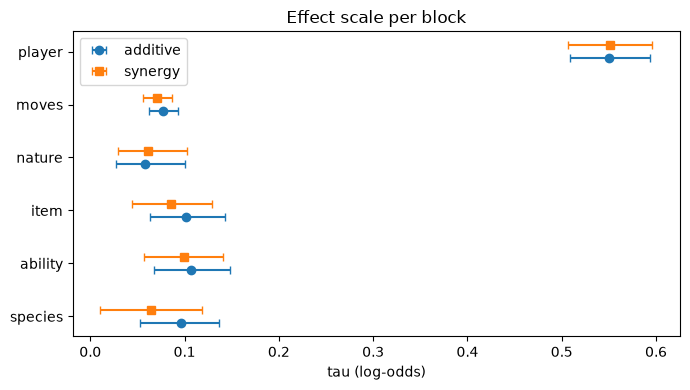

In [2]:
def tau_table(post, name):
    rows = []
    for b in ALL_BLOCKS + ["player"]:
        v = post[f"tau_{b}"].values.ravel()
        rows.append((b, v.mean(), np.percentile(v,5), np.percentile(v,95)))
    return pd.DataFrame(rows, columns=["block", f"{name}_mean", f"{name}_q5", f"{name}_q95"]).set_index("block")

tau = tau_table(post0,"add").join(tau_table(post4,"syn"))
display(tau.round(3))

fig, ax = plt.subplots(figsize=(7,4))
y = np.arange(len(tau))
ax.errorbar(tau["add_mean"], y-0.12, xerr=[tau["add_mean"]-tau["add_q5"], tau["add_q95"]-tau["add_mean"]],
            fmt="o", capsize=3, label="additive")
ax.errorbar(tau["syn_mean"], y+0.12, xerr=[tau["syn_mean"]-tau["syn_q5"], tau["syn_q95"]-tau["syn_mean"]],
            fmt="s", capsize=3, label="synergy")
ax.set_yticks(y); ax.set_yticklabels(tau.index); ax.legend(); ax.set_xlabel("tau (log-odds)")
ax.set_title("Effect scale per block"); plt.tight_layout()
plt.savefig(FIGURES/"comparison_tau.png", dpi=130); plt.show()

## Ranking helpers

In [3]:
def summarize(post, block):
    da = post[f"beta_{block}"].stack(sample=("chain","draw"))
    v = da.values
    df = pd.DataFrame({"mean": v.mean(1), "q5": np.percentile(v,5,axis=1),
                       "q95": np.percentile(v,95,axis=1)},
                      index=[str(x) for x in da[block].values])
    df["robust"] = (df["q5"] > 0) | (df["q95"] < 0)   # interval does not cross 0
    return df.sort_values("mean", ascending=False)

def forest(df, title, n=20, fname=None):
    top = pd.concat([df.head(n), df.tail(n)])
    y = np.arange(len(top))[::-1]
    colors = ["#c92a2a" if r else "#adb5bd" for r in top["robust"]]
    fig, ax = plt.subplots(figsize=(7, max(4,len(top)*0.28)))
    ax.errorbar(top["mean"], y, xerr=[top["mean"]-top["q5"], top["q95"]-top["mean"]],
                fmt="o", ms=4, ecolor="#ced4da", linestyle="none")
    ax.scatter(top["mean"], y, c=colors, s=22, zorder=3)
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(title); ax.set_xlabel("effect (log-odds) — red = interval clears zero")
    plt.tight_layout()
    if fname: plt.savefig(FIGURES/fname, dpi=130)
    plt.show()

## 2. Pokémon ranking (species effect)
Uses the **additive** model for main effects: in the synergy model part of a species' value
migrates into the latent vectors, so `beta_species` there is no longer the species' total
effect.

species with a robust effect (interval clears 0): 0 of 219


,mean,q5,q95,robust
Kangaskhan,0.107,-0.026,0.266,False
Archaludon,0.102,-0.024,0.248,False
Eternal Flower Floette,0.100,-0.019,0.232,False
Charizard,0.096,-0.017,0.218,False
Froslass,0.094,-0.032,0.238,False
Whimsicott,0.085,-0.015,0.191,False
Gardevoir,0.083,-0.043,0.235,False
Hydreigon,0.076,-0.043,0.205,False
Milotic,0.075,-0.057,0.220,False
Armarouge,0.075,-0.073,0.247,False


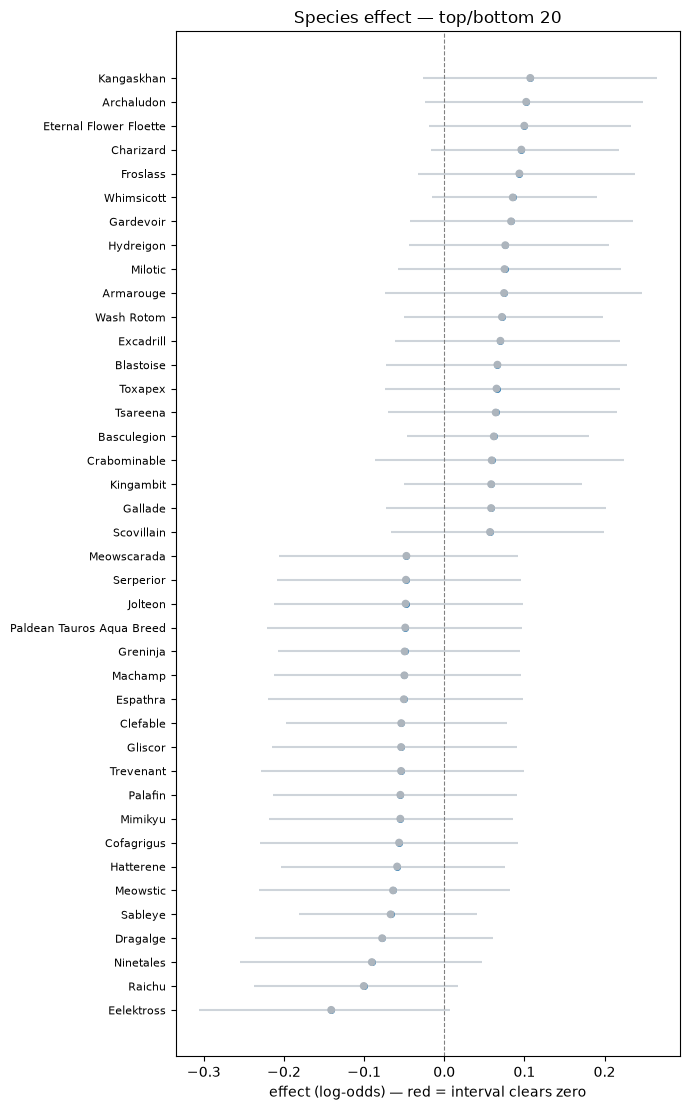

In [4]:
sp = summarize(post0, "species")
print(f"species with a robust effect (interval clears 0): {int(sp['robust'].sum())} of {len(sp)}")
display(sp.head(20).round(3))
forest(sp, "Species effect — top/bottom 20", fname="ranking_species.png")
sp.to_csv(RESULTS/"ranking_species_nuts.csv")

## 3. Items and moves

== Items, top 15 ==


,mean,q5,q95,robust
Floettite,0.143,-0.004,0.311,False
Venusaurite,0.143,0.018,0.282,True
Light Clay,0.110,0.007,0.220,True
Spell Tag,0.107,-0.033,0.266,False
Passho Berry,0.105,0.000,0.212,True
Black Glasses,0.083,-0.002,0.170,False
Blastoisinite,0.078,-0.064,0.238,False
Dragoninite,0.074,-0.055,0.210,False
Raichunite Y,0.066,-0.071,0.208,False
Gardevoirite,0.064,-0.077,0.219,False


== Moves, top 15 ==


,mean,q5,q95,robust
Encore,0.121,0.053,0.190,True
Weather Ball,0.115,0.043,0.189,True
Quick Guard,0.112,0.013,0.220,True
Swords Dance,0.107,0.031,0.185,True
Stomping Tantrum,0.100,0.033,0.167,True
Draining Kiss,0.089,-0.004,0.183,False
Snarl,0.086,-0.008,0.184,False
Thunderbolt,0.082,0.017,0.150,True
Gunk Shot,0.081,-0.025,0.193,False
Rage Powder,0.080,-0.017,0.181,False


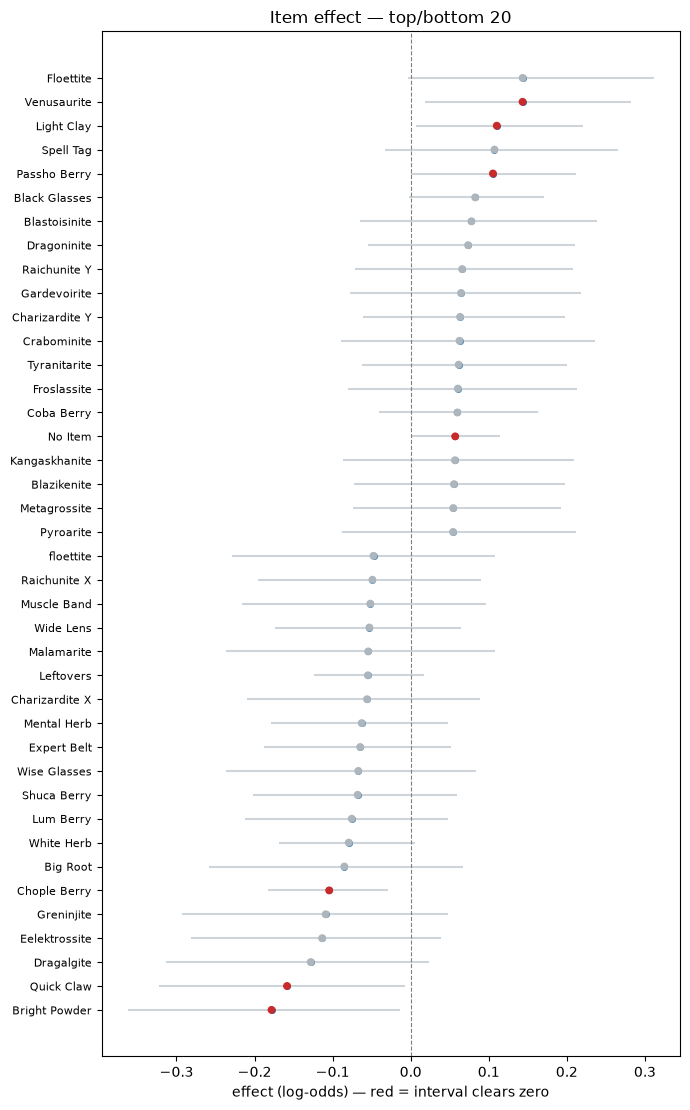

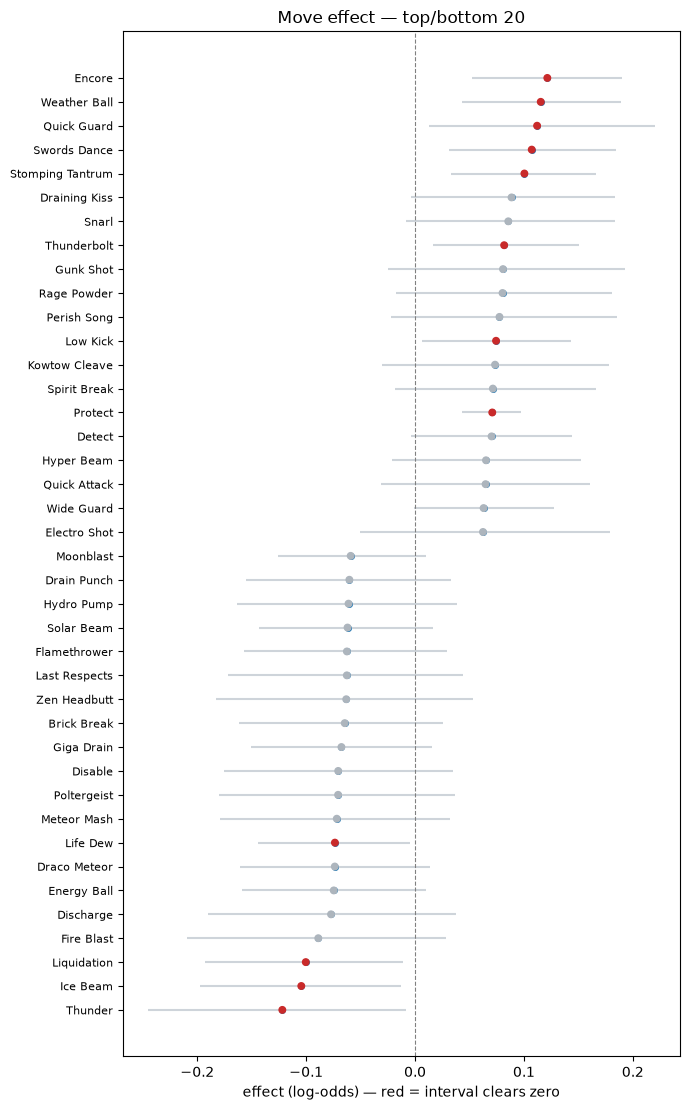

In [5]:
it = summarize(post0, "item")
mv = summarize(post0, "moves")
print("== Items, top 15 =="); display(it.head(15).round(3))
print("== Moves, top 15 =="); display(mv.head(15).round(3))
forest(it, "Item effect — top/bottom 20", fname="ranking_item.png")
forest(mv, "Move effect — top/bottom 20", fname="ranking_moves.png")
it.to_csv(RESULTS/"ranking_item_nuts.csv"); mv.to_csv(RESULTS/"ranking_moves_nuts.csv")
# abilities and natures too, for completeness
summarize(post0,"ability").to_csv(RESULTS/"ranking_ability_nuts.csv")
summarize(post0,"nature").to_csv(RESULTS/"ranking_nature_nuts.csv")

## 4. Top complete teams
Rebuilds the real teams from `teams.jsonl` (with each Pokémon's species, ability, item and
moves) and computes their posterior strength `s(team)`, excluding the player component. Shown
for **both** models, so you can see how synergy reorders them.

In [6]:
def team_key(team):
    return tuple(sorted((m["species"], m.get("item"), m.get("ability"), m.get("nature"),
                         tuple(sorted(m.get("moves", [])))) for m in team))

rows = [json.loads(l) for l in open(DATA/"teams.jsonl", encoding="utf-8")]
uniq = {}
for r in rows:
    d = uniq.setdefault(team_key(r["team"]), {"team": r["team"], "n": 0}); d["n"] += 1
MIN_OCC = 5
cand = [v for v in uniq.values() if v["n"] >= MIN_OCC]
print(f"{len(cand)} teams seen >= {MIN_OCC} times (of {len(uniq)} unique)")

def strength_matrix(post, teams):
    # vectorised: per block, counts (T x levels) @ beta samples (levels x S)
    S = post["c_side"].stack(sample=("chain","draw")).shape[0]
    out = np.zeros((len(teams), S))
    for b in ALL_BLOCKS:
        B = post[f"beta_{b}"].stack(sample=("chain","draw")).values
        idx = {str(l): i for i, l in enumerate(post[b].values)}
        C = np.zeros((len(teams), B.shape[0]))
        for i, v in enumerate(teams):
            cnt = collections.Counter()
            for mon in v["team"]:
                if b == "moves":
                    for mvv in mon["moves"]: cnt[mvv]+=1
                else: cnt[mon[b]]+=1
            for lv, k in cnt.items():
                j = idx.get(str(lv))
                if j is not None: C[i,j]+=k
        out += C @ B
    if "V_species" in post:
        V = post["V_species"].stack(sample=("chain","draw")).values   # (species, syn, S)
        idx = {str(l): i for i,l in enumerate(post["species"].values)}
        ns, nsyn, S = V.shape
        for i, v in enumerate(teams):
            cnt = collections.Counter(m["species"] for m in v["team"])
            sc = np.zeros(ns)
            for lv,k in cnt.items():
                j = idx.get(str(lv))
                if j is not None: sc[j]+=k
            z = np.einsum("s,sfS->fS", sc, V)                # (syn, S)
            self_t = np.einsum("s,sfS->S", sc, V**2)         # (S,)
            out[i] += 0.5*((z**2).sum(0) - self_t)
    return out

def rank_df(post, teams):
    M = strength_matrix(post, teams)
    df = pd.DataFrame({
        "team": [" / ".join(m["species"] for m in v["team"]) for v in teams],
        "n": [v["n"] for v in teams],
        "mean": M.mean(1), "q5": np.percentile(M,5,axis=1), "q95": np.percentile(M,95,axis=1),
    })
    df["_team"] = [v["team"] for v in teams]
    return df.sort_values("mean", ascending=False).reset_index(drop=True)

rank_add = rank_df(post0, cand)
rank_syn = rank_df(post4, cand)
print("\n=== TOP 15 — additive model ===")
display(rank_add.head(15)[["team","n","mean","q5","q95"]].round(3))
print("=== TOP 15 — synergy model ===")
display(rank_syn.head(15)[["team","n","mean","q5","q95"]].round(3))
rank_add.drop(columns="_team").to_csv(RESULTS/"ranking_teams_add.csv", index=False)
rank_syn.drop(columns="_team").to_csv(RESULTS/"ranking_teams_syn.csv", index=False)

95 teams seen >= 5 times (of 5393 unique)

=== TOP 15 — additive model ===


,team,n,mean,q5,q95
0,Sneasler / Blastoise / Kingambit / Incineroar ...,7,2.048,1.691,2.412
1,Blastoise / Delphox / Sneasler / Incineroar / ...,5,1.899,1.554,2.257
2,Delphox / Eternal Flower Floette / Sinistcha /...,7,1.815,1.484,2.158
3,Froslass / Scovillain / Basculegion / Kingambi...,8,1.815,1.460,2.191
4,Sinistcha / Kingambit / Sneasler / Eternal Flo...,8,1.808,1.476,2.149
5,Froslass / Scovillain / Sneasler / Kingambit /...,7,1.681,1.342,2.039
6,Charizard / Eternal Flower Floette / Aegislash...,5,1.628,1.216,2.051
7,Froslass / Scovillain / Basculegion / Kingambi...,5,1.623,1.281,1.984
8,Swampert / Pelipper / Archaludon / Venusaur / ...,7,1.587,1.227,1.946
9,Charizard / Sylveon / Aerodactyl / Farigiraf /...,5,1.585,1.256,1.917


=== TOP 15 — synergy model ===


,team,n,mean,q5,q95
0,Sneasler / Blastoise / Kingambit / Incineroar ...,7,2.067,1.701,2.440
1,Blastoise / Delphox / Sneasler / Incineroar / ...,5,1.934,1.564,2.295
2,Delphox / Eternal Flower Floette / Sinistcha /...,7,1.911,1.581,2.252
3,Sinistcha / Kingambit / Sneasler / Eternal Flo...,8,1.909,1.586,2.251
4,Froslass / Scovillain / Basculegion / Kingambi...,8,1.845,1.483,2.215
5,Basculegion / Kingambit / Sneasler / Incineroa...,7,1.777,1.395,2.180
6,Gengar / Swampert / Incineroar / Politoed / Ar...,8,1.772,1.339,2.225
7,Froslass / Scovillain / Sneasler / Kingambit /...,7,1.728,1.372,2.082
8,Sinistcha / Incineroar / Milotic / Raichu / Et...,21,1.701,1.349,2.074
9,Froslass / Scovillain / Basculegion / Kingambi...,5,1.665,1.307,2.017


### Best team detail
Complete set of the team at the top of the additive ranking.

In [7]:
best = rank_add.iloc[0]["_team"]
det = pd.DataFrame([{"species": m["species"], "ability": m.get("ability"),
                     "item": m.get("item"), "nature": m.get("nature"),
                     "moves": ", ".join(m.get("moves", []))} for m in best])
display(det)

,species,ability,item,nature,moves
0,Sneasler,Poison Touch,Focus Sash,Jolly,"Poison Jab, Close Combat, Fake Out, Quick Guard"
1,Blastoise,Rain Dish,Blastoisinite,Modest,"Dark Pulse, Water Spout, Shell Smash, Protect"
2,Kingambit,Defiant,Black Glasses,Adamant,"Kowtow Cleave, Sucker Punch, Swords Dance, Pro..."
3,Incineroar,Intimidate,Sitrus Berry,Careful,"Flare Blitz, Helping Hand, Parting Shot, Fake Out"
4,Delphox,Blaze,Delphoxite,Modest,"Heat Wave, Nasty Plot, Psyshock, Protect"
5,Sinistcha,Hospitality,Kasib Berry,Bold,"Matcha Gotcha, Rage Powder, Trick Room, Protect"


### Forest plot of the top 15 teams (additive)

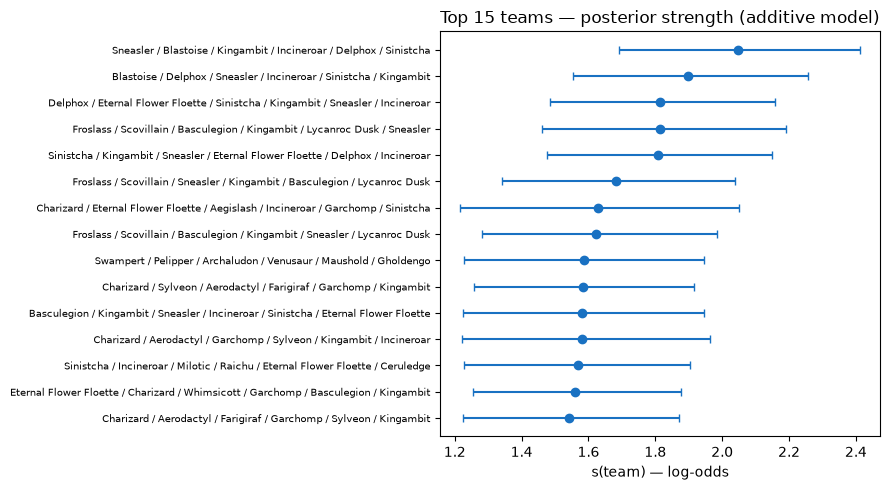

In [8]:
top = rank_add.head(15)[::-1]
y = np.arange(len(top))
fig, ax = plt.subplots(figsize=(9,5))
ax.errorbar(top["mean"], y, xerr=[top["mean"]-top["q5"], top["q95"]-top["mean"]],
            fmt="o", color="#1971c2", capsize=3)
ax.set_yticks(y); ax.set_yticklabels(top["team"], fontsize=7)
ax.set_title("Top 15 teams — posterior strength (additive model)")
ax.set_xlabel("s(team) — log-odds")
plt.tight_layout(); plt.savefig(FIGURES/"ranking_teams.png", dpi=130); plt.show()

## 5. Strongest synergies (synergy model)
For each species pair, the posterior mean inner product of their latent vectors. Positive =
they reinforce each other (core), negative = redundancy / anti-synergy. Only pairs that
actually appear together in the data.

In [9]:
V = post4["V_species"].stack(sample=("chain","draw")).values   # (species, syn, S)
sp_labels = [str(x) for x in post4["species"].values]

# pairs actually seen together
pairs_seen = collections.Counter()
for r in rows:
    specs = sorted(set(m["species"] for m in r["team"]))
    for i in range(len(specs)):
        for j in range(i+1, len(specs)):
            pairs_seen[(specs[i], specs[j])] += 1

idx = {l:i for i,l in enumerate(sp_labels)}
recs = []
for (a,b), c in pairs_seen.items():
    if c < 5 or a not in idx or b not in idx: continue
    dots = np.einsum("fS,fS->S", V[idx[a]], V[idx[b]])   # (S,)
    recs.append((a, b, c, dots.mean(), np.percentile(dots,5), np.percentile(dots,95)))
syn = pd.DataFrame(recs, columns=["species_1","species_2","n","mean","q5","q95"])
syn["robust"] = (syn["q5"]>0)|(syn["q95"]<0)

print("== Strongest POSITIVE synergies (cores) ==")
display(syn.sort_values("mean", ascending=False).head(15).round(3))
print("== Strongest NEGATIVE synergies (redundancies) ==")
display(syn.sort_values("mean").head(15).round(3))
syn.sort_values("mean", ascending=False).to_csv(RESULTS/"synergy_pairs.csv", index=False)

== Strongest POSITIVE synergies (cores) ==


,species_1,species_2,n,mean,q5,q95,robust
196,Archaludon,Grimmsnarl,495,0.095,0.003,0.206,True
95,Kingambit,Sneasler,567,0.091,0.019,0.172,True
94,Kingambit,Sinistcha,388,0.089,0.019,0.170,True
92,Eternal Flower Floette,Kingambit,571,0.080,0.007,0.162,True
840,Gengar,Grimmsnarl,32,0.079,-0.027,0.204,False
314,Sinistcha,Tyranitar,136,0.078,-0.013,0.194,False
312,Gholdengo,Tyranitar,42,0.076,-0.014,0.197,False
51,Blaziken,Kingambit,199,0.075,-0.014,0.176,False
718,Gholdengo,Scovillain,45,0.074,-0.023,0.207,False
270,Charizard,Hydreigon,161,0.070,-0.016,0.175,False


== Strongest NEGATIVE synergies (redundancies) ==


,species_1,species_2,n,mean,q5,q95,robust
764,Grimmsnarl,Kingambit,65,-0.081,-0.181,0.008,False
592,Archaludon,Kingambit,56,-0.081,-0.192,0.014,False
1640,Eternal Flower Floette,Gengar,5,-0.077,-0.209,0.027,False
242,Alolan Ninetales,Charizard,21,-0.072,-0.194,0.021,False
10,Farigiraf,Kingambit,504,-0.071,-0.153,0.003,False
648,Archaludon,Sneasler,143,-0.071,-0.181,0.016,False
927,Blaziken,Farigiraf,59,-0.071,-0.180,0.014,False
406,Eternal Flower Floette,Grimmsnarl,134,-0.069,-0.168,0.020,False
178,Farigiraf,Sinistcha,159,-0.068,-0.153,0.011,False
524,Annihilape,Sinistcha,55,-0.068,-0.182,0.030,False


## How to read this

- **Main effects from the additive model**, synergies from the synergy model: in the latter,
  part of a species' value migrates into the latent vectors, so `beta_species` there is partial.
- **Red in the forest plots** = interval that clears zero, i.e. an established effect.
  Grey = compatible with zero, do not over-interpret.
- **Team strengths exclude the pilot**: they answer "how strong is this team, holding the
  player constant", not "how often it wins in practice".
- Which model is better is decided by **held-out log-loss**, not by these rankings: that is the
  validation cell in `analisi_vgc.ipynb`, to be run on both tags.